In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"satriomuktiprayoga","key":"e0fff387357eb1ac9969841cb3ef8b77"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets download -d yasserh/housing-prices-dataset

  0% 0.00/4.63k [00:00<?, ?B/s]
100% 4.63k/4.63k [00:00<00:00, 6.98MB/s]


In [38]:
!unzip housing-prices-dataset.zip

Archive:  housing-prices-dataset.zip
  inflating: Housing.csv             


# Library yang akan digunakan

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Memanggil Dataset

In [41]:
df = pd.read_csv('Housing.csv')

# Deskripsi Dataset

In [42]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [43]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


# Cek data null

In [44]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

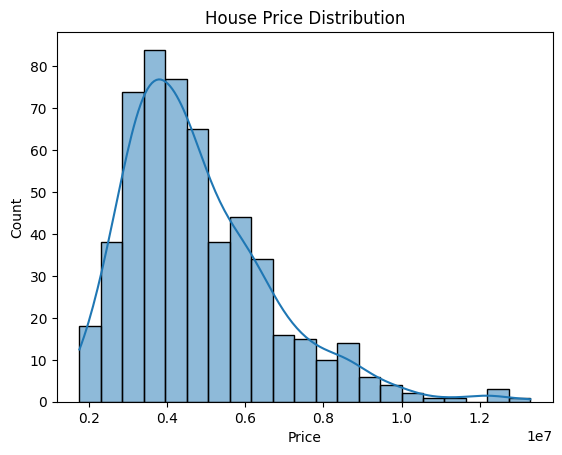

In [45]:
plt.figure
sns.histplot(df['price'], kde=True)
plt.title('House Price Distribution')
plt.xlabel('Price')
plt.show()

<Axes: xlabel='airconditioning', ylabel='bedrooms'>

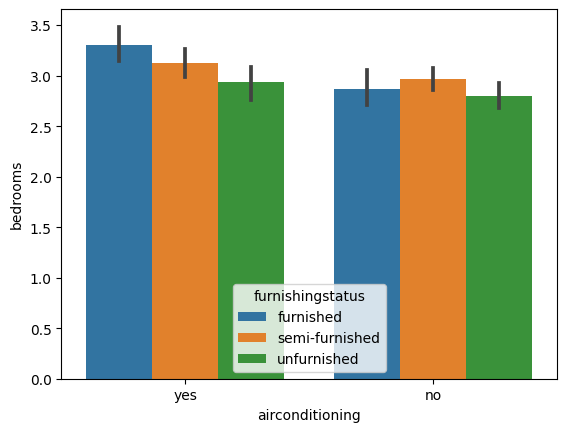

In [46]:
sns.barplot(x=df['airconditioning'],y=df['bedrooms'],hue=df["furnishingstatus"])

<Axes: >

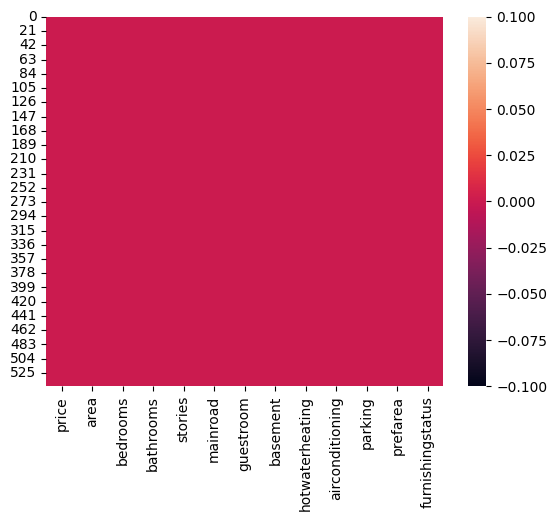

In [47]:
sns.heatmap(df.isnull())

In [48]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


<Axes: >

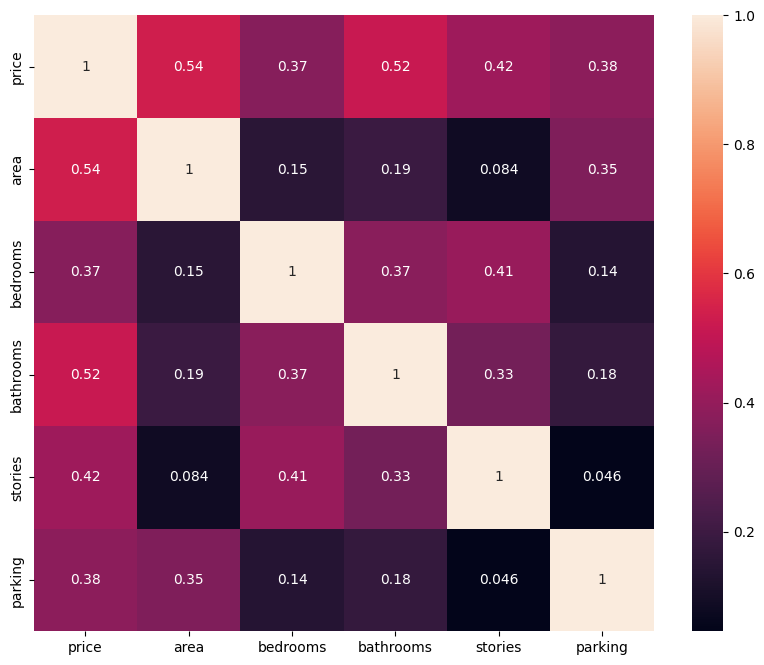

In [49]:
    plt.figure(figsize=(10,8))
    sns.heatmap(df.corr(numeric_only=True),annot=True)

In [50]:
ac = df.groupby('airconditioning').count()[['price']].sort_values(by='price',ascending=True).reset_index()
ac = ac.rename(columns={'price':'numberOfAircondition'})

(array([0, 1]), [Text(0, 0, 'yes'), Text(1, 0, 'no')])

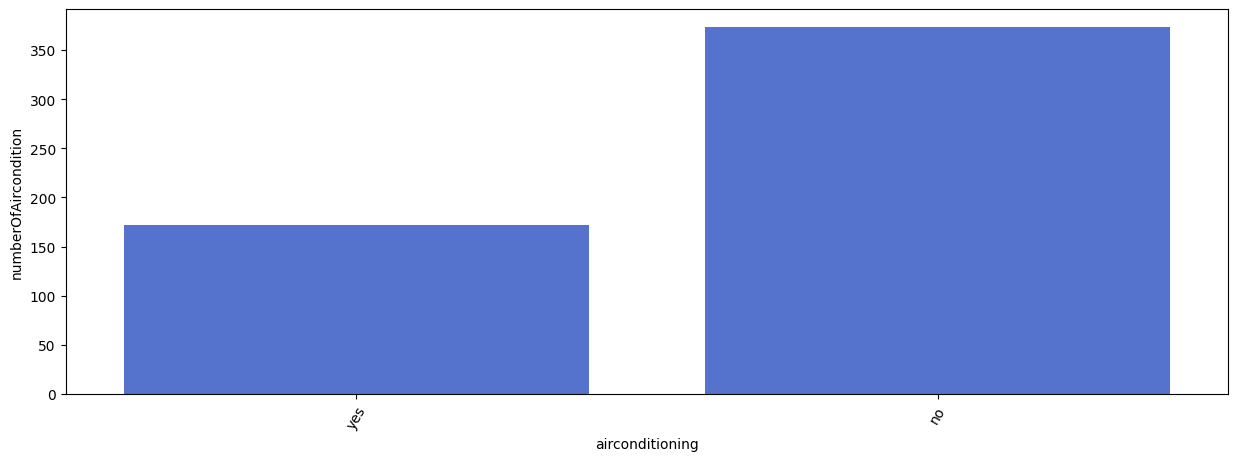

In [51]:
fig = plt.figure(figsize=(15,5))
sns.barplot(x=ac['airconditioning'], y=ac['numberOfAircondition'],color='royalblue')
plt.xticks(rotation=60)

<Axes: xlabel='area', ylabel='price'>

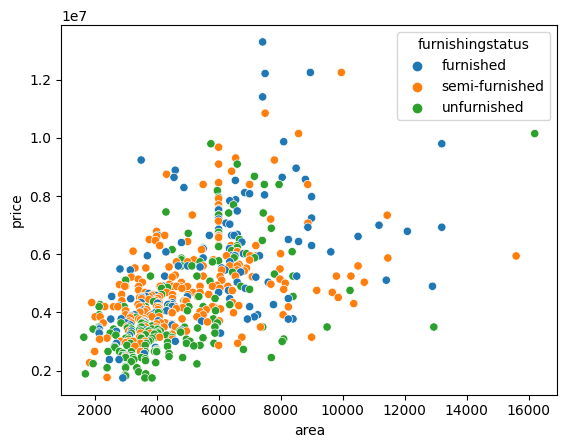

In [52]:
sns.scatterplot(y=df['price'],x=df['area'],hue=df['furnishingstatus'])

In [53]:
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea','furnishingstatus']

# Mengganti nilai 'yes' dan 'no' dengan True dan False
df.replace({'yes': True, 'no': False}, inplace=True)

# Menggunakan map() untuk mengubah nilai kategori menjadi numerik
encoding = {'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}
df['furnishingstatus'] = df['furnishingstatus'].map(encoding)

x = df[features]
y = df['price']
x.shape, y.shape

((545, 12), (545,))

In [54]:
x_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2 ,random_state=50)

In [55]:
y_test.shape

(109,)

In [56]:
lr = LinearRegression()
lr.fit(x_train,y_train)
pred = lr.predict(X_test)

In [57]:
# ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
input_data = np.array([[3000, 2, 1, 1, 1, 0, 1, 0, 0, 2, 1, 0]])
input_df = pd.DataFrame(input_data, columns=features)

prediction = lr.predict(input_df)
print('Estimasi harga rumah (INR) : ', prediction)

Estimasi harga rumah (INR) :  [4117611.75012809]


In [58]:
lr = LinearRegression()
lr.fit(x_train,y_train)
pred = lr.predict(X_test)

score = lr.score(X_test, y_test)
print('akurasi model regresi linier = ', score*100,"%")

akurasi model regresi linier =  76.24579467323477 %


In [59]:
import pickle

In [60]:
filename = 'estimasi-rumah.sav'
pickle.dump(lr,open(filename,'wb'))